## Calculant el volum d'una esfera modificant el mètode per al càlcul de Pi


In [1]:
# Posem les llibreries importants que utilitzarem
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Fem el input total de punts random
total_random_points = int(input("\nEnter number of points for Monte Carlo estimate of Pi?\n>"))


Enter number of points for Monte Carlo estimate of Pi?
>5000


En aquest bloc posem per a calcular el volum de l'esfera

In [3]:
# Comptador inicial del nombre de punts dins de l'esfera i dins del cub
inside_sphere = 0
inside_cube = 0

#Creem una lista per a guardar x,y,z de punts dins de l'esfera
xc = []
yc = []
zc = []

# Creem una lista per a guardar x,y,z de punts fora de l'esfera
xs = []
ys = []
zs = []

#Calculs

# Generem tots els random pints per a x,y,z
x = np.random.uniform(-1.0, 1.0, total_random_points)
y = np.random.uniform(-1.0, 1.0, total_random_points)
z = np.random.uniform(-1.0, 1.0, total_random_points)

for i in range(total_random_points):
    inside_cube = inside_cube + 1 # Cada punt está dins del cub

    # Comprovem si està dins de l'esfera
    if x[i]**2 + y[i]**2 + z[i]**2 <= 1.0:
        inside_sphere = inside_sphere + 1
        xc.append(x[i])
        yc.append(y[i])
        zc.append(z[i])
    else:
        xs.append(x[i])
        ys.append(y[i])
        zs.append(z[i])

#---------------------------------------------------

**Grafiquem els resultats**

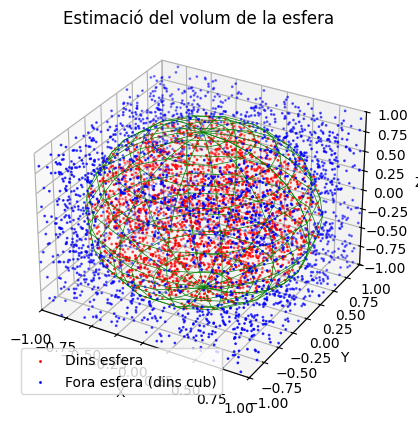

In [4]:
from mpl_toolkits.mplot3d import Axes3D

# Creem una nova figura
fig = plt.figure()
# Afegim un 3D subplot
ax = fig.add_subplot(111, projection='3d')

# Grafiquem els punts dins de l'esfera de color vermell
ax.scatter(xc, yc, zc, c='r', marker='o', s=1.0, label='Dins esfera')

# Grafiquem els punts fora de l'esfera pero dins del cub de color blau
ax.scatter(xs, ys, zs, c='b', marker='o', s=1.0, label='Fora esfera (dins cub)')

# Afegim una esfera (wireframe) per poder observar millor la forma al gràfic
u = np.linspace(0, 2 * np.pi, 15)
v = np.linspace(0, np.pi, 15)
x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='green', linewidth=0.5)

#Afegim titols
ax.set_title('Estimació del volum de la esfera')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Posem limits visuals per al cub
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])

# Afegim llegenda
ax.legend()

# Mostrem el plot en pantalla
plt.show()

**Calculem les estadistiques**

In [5]:
#Nombre de punts dins de la esfera en comparació amb el total
sphere_ratio = inside_sphere / inside_cube

#Nnombre de punts dins de la esfera en comparació amb els que hi ha dins del cub total amb una àrea de 8,0
sphere_approx = 8.0*sphere_ratio

# Definim el volum calculat i el exacte
volum_estimat = sphere_approx
volum_exacte = (4/3) * np.pi

#print output
print('\n--------------')
print('\nResultats 3D')
print('\nNombre de punts dins del cub de volum 8:', inside_cube)
print('Número de punts dins de la esfera unitària:', inside_sphere)
print('Ratio esfera / cub =', sphere_ratio * 100, '% \n')
print('Volum estimat de lesfera =', sphere_ratio, 'x 8 =', volum_estimat)
print('Valor analític exacte:', volum_exacte)
print('Error relatiu:', abs(volum_estimat - volum_exacte) / volum_exacte * 100, '%')



--------------

Resultats 3D

Nombre de punts dins del cub de volum 8: 5000
Número de punts dins de la esfera unitària: 2599
Ratio esfera / cub = 51.980000000000004 % 

Volum estimat de lesfera = 0.5198 x 8 = 4.1584
Valor analític exacte: 4.1887902047863905
Error relatiu: 0.725512696999347 %
